# M1.Ex1: Model Hours vs Marks

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M1/exercises/ex1_reg.ipynb)
- Raw Dataset: [Rounded_Student_Hours_Studied_vs_Marks_Dataset.csv](https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/Rounded_Student_Hours_Studied_vs_Marks_Dataset.csv)

In [144]:
import pandas as pd
import sklearn
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error



import seaborn as sns
import matplotlib.pyplot as plt

### Step 1. Load the data

In [145]:
df=pd.read_csv("https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/Rounded_Student_Hours_Studied_vs_Marks_Dataset.csv")

In [146]:
df.head()


,Hours_Studied,Marks
0,4.76,46.27
1,3.00,34.30
2,2.08,33.63
3,4.04,47.81
4,9.49,66.26


### Step 2.a Assign variables `X` to the features and `y` to the target

In [147]:
x=df[['Hours_Studied']]
y=df['Marks']

### Step 2.b print the type of each

In [148]:
print(type(x))
print(type(y))

<class 'pandas.DataFrame'>
<class 'pandas.Series'>


### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

In [149]:
print(y.dtypes)
print("The Target is Numerical so we will use regression")

float64
The Target is Numerical so we will use regression


### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [150]:
print(f'Features Shape {x.shape}, Target Shape {y.shape}')

Features Shape (100, 1), Target Shape (100,)


### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [151]:
df.describe()

,Hours_Studied,Marks
count,100.000000,100.000000
mean,5.376300,46.360200
std,2.593013,14.284805
min,1.050000,20.190000
25%,3.175000,33.675000
50%,5.565000,47.485000
75%,7.255000,57.377500
max,9.870000,73.260000


### Step 5. Plot the feature vs the target

Text(0.5, 1.0, 'Feature vs Target Scatterplot')

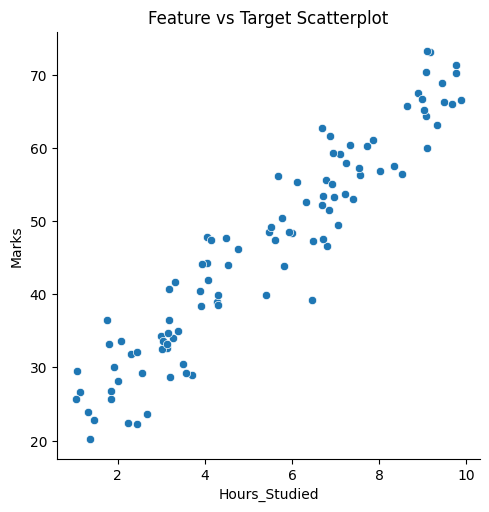

In [152]:
sns.relplot(data=df,x=x['Hours_Studied'],y=y)

plt.title("Feature vs Target Scatterplot")

### Step 6. What is the relationship between the feature and the target? (increasing or decreasing or none)

In [153]:
corr= df['Hours_Studied'].corr(df['Marks'])
print(f"The correlation between (Hours Studied) and (Marks) is {corr:.2f} \nSo there is a Positive correlation")


The correlation between (Hours Studied) and (Marks) is 0.95 
So there is a Positive correlation


### Step 7. Initialize a `LinearRegression` model

In [154]:
model = LinearRegression()

### Step 8. Split the dataset into train and test sets

In [155]:
x_train, x_test , y_train , y_test= train_test_split(x,y,test_size=0.2,random_state=42) #set random seed for same output 

### Step 9.a Train the model on the training set

In [156]:
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Step 9.b Identify the learned slope and the y-intercept of the model

In [157]:
intercept = model.intercept_
slope=model.coef_
print(f'intercept: {intercept:.2f}')
print(f'Slope : {slope[0]:.2f}')

intercept: 18.54
Slope : 5.16


### Step 9.c how much marks do we get per 1 hour of study?

In [158]:
print(f"per 1 hour of study we get {slope[0]:.2f} Marks")

per 1 hour of study we get 5.16 Marks


### Step 9.d how much does a 10 minutes increase of study time adds to our marks?

In [159]:
print(f"10 mins of study will add {(slope/6)[0]:.2f} marks")

10 mins of study will add 0.86 marks


### Step 9.e if one doesn't study at all, how much marks do they get?

In [160]:
no_study_grade=model.predict([[0]])

print(f'if one doesnt study at all he will get {no_study_grade[0]:.2f}')


if one doesnt study at all he will get 18.54


/Users/turkialomran/Desktop/SDAIA_Bootcamp/AAI/AAI/content/W3/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


### Step 10. Evaluate the model on the test set

In [161]:
inferred_test=model.predict(x_test)
error =mean_absolute_error(y_test,inferred_test)
print(f'Mean absolute error is {error:.2f}')

r2=model.score(x_test,y_test)

print(f'R2 score is : {r2:.2f}')


Mean absolute error is 2.99
R2 score is : 0.93


### Step 11. Take a sample of three rows from the test set and make a prediction on them and check whether they match the true label or not

In [162]:
sample=x_test.sample(3,random_state=42)
predictions=model.predict(sample) 
actual=y_test[sample.index] #here we pass the index of the sample so we get the values of target for corresponding feature

sample=pd.DataFrame({'Hours Studied': sample['Hours_Studied'],'Actual':actual,"predicted":predictions})
sample



,Hours Studied,Actual,predicted
83,3.02,32.50,34.135183
77,6.97,53.36,54.534714
4,9.49,66.26,67.549099


### Step 12. Plot the data and the regression line

Text(0.5, 1.0, 'Hours vs Marks Scatterplot With Regression Line')

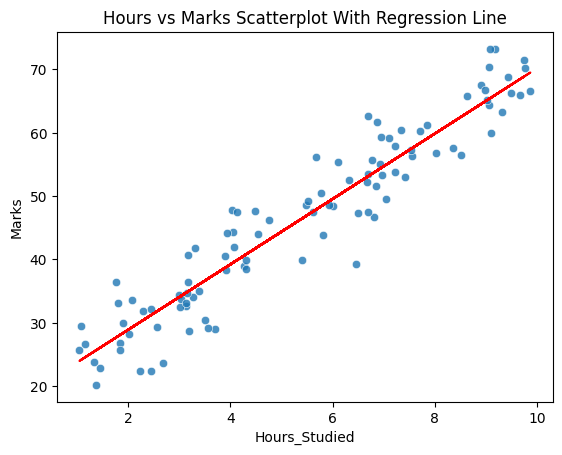

In [178]:
predicted=model.predict(x)

fig, ax = plt.subplots()                                                                                                

sns.scatterplot(data=df,x=x['Hours_Studied'],y=y,alpha=0.8,ax=ax)
ax.plot(df['Hours_Studied'],predicted,color='red')
ax.set_title("Hours vs Marks Scatterplot With Regression Line")
